# Oracle evaluation
Loads the best checkpoint, runs inference on val and test sets, and compares to SAIR baselines.

In [1]:
import sys
sys.path.insert(0, '..')

import os
os.environ.setdefault('PYTORCH_MPS_HIGH_WATERMARK_RATIO', '0.0')

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

from oracle import IC50Oracle, SAIRDataset
from scripts.train import collate_fn

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

In [2]:
CKPT_PATH    = Path('../checkpoints/best.pt')
PARQUET      = Path('../data/sair.parquet')
ESM_CACHE    = Path('../data/esm_embeddings/')
LIGAND_CACHE = Path('../data/ligand_cache.pt')
ANNOTATIONS  = Path('../data/long_protein_annotations.csv')
SPLITS_DIR   = Path('../data/splits/')
BATCH_SIZE   = 512

device = (
    torch.device('cuda') if torch.cuda.is_available()
    else torch.device('mps') if torch.backends.mps.is_available()
    else torch.device('cpu')
)
print(f'Device: {device}')

Device: mps


## 1. Load model from checkpoint

In [3]:
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model = IC50Oracle.from_config(ckpt['config']).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f"Checkpoint: epoch {ckpt['epoch']}  val_spearman={ckpt['val_spearman']:.4f}  val_mae={ckpt['val_mae']:.4f}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Checkpoint: epoch 27  val_spearman=0.3962  val_mae=1.0318
Parameters: 1,658,113


## 2. Build val and test datasets

In [4]:
def load_ids(split):
    return (SPLITS_DIR / f'{split}.txt').read_text().splitlines()

dataset_kwargs = dict(
    parquet_path      = PARQUET,
    esm_cache_dir     = ESM_CACHE,
    annotations_csv   = ANNOTATIONS,
    filter_all_passed = True,
    assay_filter      = 'biochem',
    deduplicate       = True,
    ligand_cache_path = LIGAND_CACHE,
)

val_ds  = SAIRDataset(entry_ids=load_ids('val'),  **dataset_kwargs)
test_ds = SAIRDataset(entry_ids=load_ids('test'), **dataset_kwargs)
print(f'Val:  {len(val_ds):,} samples  |  Test: {len(test_ds):,} samples')

Protein filter loaded: 3,563 proteins allowed
Protein filter: 2,254,568 -> 2,032,088 rows (dropped 222,480)
Dataset ready: 41,269 samples across 354 proteins
Pre-loading 354 mean-pooled ESM embeddings (legacy mode) ... done (1 MB, legacy mean-pool mode)
Loading ligand cache from ../data/ligand_cache.pt ... done (37,992 entries)
Protein filter loaded: 3,563 proteins allowed
Protein filter: 2,254,568 -> 2,032,088 rows (dropped 222,480)
Dataset ready: 42,705 samples across 350 proteins
Pre-loading 350 mean-pooled ESM embeddings (legacy mode) ... done (1 MB, legacy mean-pool mode)
Loading ligand cache from ../data/ligand_cache.pt ... done (39,669 entries)
Val:  41,269 samples  |  Test: 42,705 samples


## 3. Run inference

In [5]:
@torch.no_grad()
def run_inference(dataset, batch_size=BATCH_SIZE):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, collate_fn=collate_fn)
    preds, targets, proteins = [], [], []
    for residues, prot_mask, graphs, descriptors, pic50s, _, protein_names in tqdm(loader):
        residues    = residues.to(device)
        prot_mask   = prot_mask.to(device)
        graphs      = graphs.to(device)
        descriptors = descriptors.to(device)
        p = model(residues, prot_mask, graphs, descriptors).float().cpu()
        preds.append(p)
        targets.append(pic50s)
        proteins.extend(protein_names)
        if device.type == 'mps':
            torch.mps.empty_cache()

    df = dataset.df[['entry_id', 'protein', 'SMILES', 'pIC50']].copy().reset_index(drop=True)
    df['pred_pIC50'] = torch.cat(preds).numpy()
    return df

val_df  = run_inference(val_ds)
test_df = run_inference(test_ds)
print('Done.')

  0%|          | 0/81 [00:00<?, ?it/s]

  0%|          | 0/84 [00:00<?, ?it/s]

Done.


In [6]:
# Merge in baseline scores and protein family from parquet
parquet_cols = ['entry_id', 'family', 'vina_score', 'vinardo_score',
                'aevplig_score', 'onionnet_score', 'vina_score_min']
meta = pd.read_parquet(PARQUET, columns=parquet_cols)

val_df  = val_df.merge(meta,  on='entry_id', how='left')
test_df = test_df.merge(meta, on='entry_id', how='left')
val_df.head(3)

,entry_id,protein,SMILES,pIC50,pred_pIC50,family,vina_score,vinardo_score,aevplig_score,onionnet_score,vina_score_min
0,754593,P55263,Nc1ncnc2c1c(I)cn2[C@@H]1O[C@H](CO)[C@@H](O)[C@...,6.09,5.198074,kinase,-9.7139,-9.7905,6.532362,7.14,-10.6641
1,754593,P55263,Nc1ncnc2c1c(I)cn2[C@@H]1O[C@H](CO)[C@@H](O)[C@...,6.09,5.198074,kinase,-9.7139,-9.7905,6.532362,7.14,-10.6641
2,754593,P55263,Nc1ncnc2c1c(I)cn2[C@@H]1O[C@H](CO)[C@@H](O)[C@...,6.09,5.198074,kinase,-9.7139,-9.7905,6.532362,7.14,-10.6641


## 4. Overall metrics

In [7]:
def metrics(df, pred_col, target_col='pIC50', label=''):
    mask = df[pred_col].notna() & df[target_col].notna()
    p = df.loc[mask, pred_col].values
    t = df.loc[mask, target_col].values
    return {
        'model': label,
        'n': mask.sum(),
        'spearman': spearmanr(p, t).statistic,
        'pearson':  pearsonr(p, t)[0],
        'mae':      float(np.abs(p - t).mean()),
        'rmse':     float(np.sqrt(((p - t)**2).mean())),
    }

# Docking scores are negative (lower = better) — negate for fair Spearman comparison
for df in [val_df, test_df]:
    for col in ['vina_score', 'vinardo_score', 'vina_score_min']:
        df[f'{col}_neg'] = -df[col]

rows = []
for split_label, df in [('val', val_df), ('test', test_df)]:
    rows.append({**metrics(df, 'pred_pIC50',         label='Oracle'),        'split': split_label})
    rows.append({**metrics(df, 'aevplig_score',      label='AEVPLig'),       'split': split_label})
    rows.append({**metrics(df, 'onionnet_score',     label='OnionNet'),      'split': split_label})
    rows.append({**metrics(df, 'vina_score_neg',     label='Vina (neg)'),    'split': split_label})
    rows.append({**metrics(df, 'vinardo_score_neg',  label='Vinardo (neg)'), 'split': split_label})

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df[['split', 'model', 'n', 'spearman', 'pearson', 'mae', 'rmse']]
print(metrics_df.to_string(index=False, float_format='{:.4f}'.format))

split         model      n  spearman  pearson    mae   rmse
  val        Oracle 435410    0.3938   0.4152 1.0348 1.2991
  val       AEVPLig 424949    0.3511   0.3720 1.0374 1.2750
  val      OnionNet 409130    0.3098   0.2892 1.1626 1.4376
  val    Vina (neg) 430098    0.2457   0.1513 3.1199 4.8305
  val Vinardo (neg) 430098    0.2386   0.1404 4.0615 6.5071
 test        Oracle 435240    0.3864   0.3874 1.1300 1.4143
 test       AEVPLig 426629    0.3565   0.3687 1.0917 1.3444
 test      OnionNet 408518    0.3381   0.3224 1.1576 1.4307
 test    Vina (neg) 431940    0.3424   0.2361 2.9578 4.9296
 test Vinardo (neg) 431940    0.3118   0.2034 3.8144 6.6323


## 5. Predicted vs actual scatter (coloured by protein family)

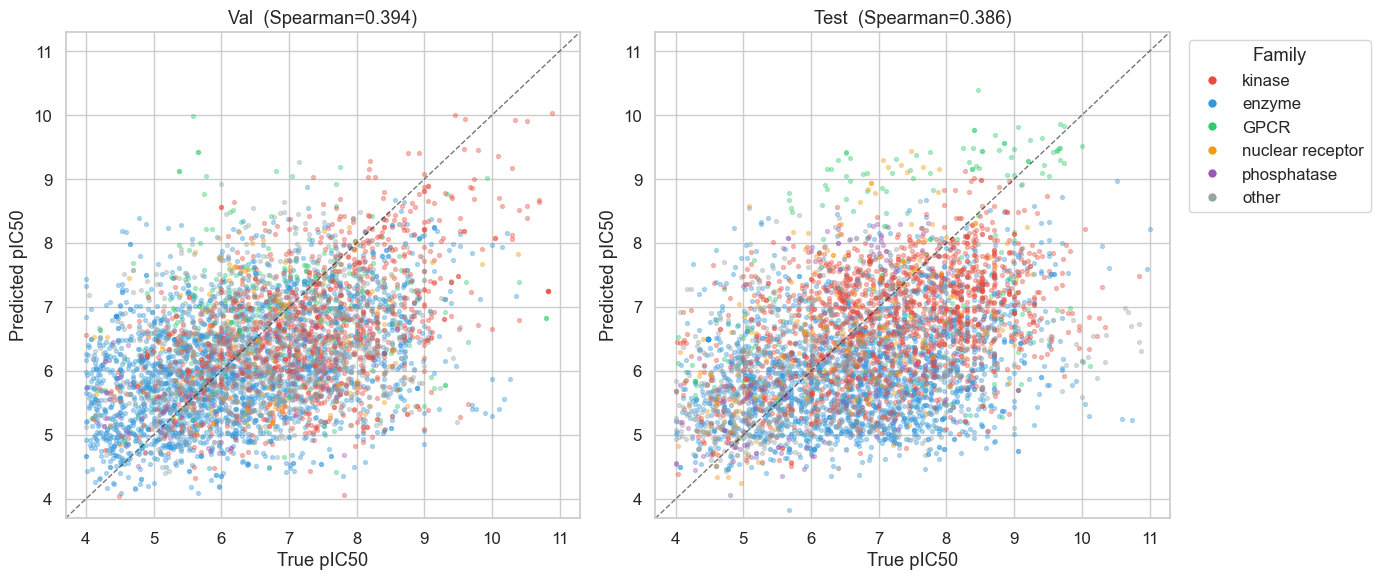

In [10]:
FAMILY_COLORS = {
    'kinase':           '#e74c3c',
    'enzyme':           '#3498db',
    'GPCR':             '#2ecc71',
    'nuclear receptor': '#f39c12',
    'phosphatase':      '#9b59b6',
    'other':            '#95a5a6',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (split_label, df) in zip(axes, [('Val', val_df), ('Test', test_df)]):
    sample = df.sample(min(5000, len(df)), random_state=42)
    for family, grp in sample.groupby('family'):
        ax.scatter(grp['pIC50'], grp['pred_pIC50'],
                   c=FAMILY_COLORS.get(family, '#95a5a6'),
                   alpha=0.35, s=8, label=family, rasterized=True)
    lo = df['pIC50'].min() - 0.3
    # lo = 0.0
    hi = df['pIC50'].max() + 0.3
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.6)
    sp = spearmanr(df['pIC50'], df['pred_pIC50']).statistic
    ax.set_title(f'{split_label}  (Spearman={sp:.3f})')
    ax.set_xlabel('True pIC50')
    ax.set_ylabel('Predicted pIC50')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=7, label=f)
           for f, c in FAMILY_COLORS.items()]
axes[1].legend(handles=handles, title='Family', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../checkpoints/scatter_val_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Per-protein Spearman distribution

/var/folders/cq/_rhlqkqs7tqb1mb8ksc9mn6h0000gn/T/ipykernel_34405/3826601907.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp = spearmanr(grp[target_col], grp[pred_col]).statistic
/var/folders/cq/_rhlqkqs7tqb1mb8ksc9mn6h0000gn/T/ipykernel_34405/3826601907.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp = spearmanr(grp[target_col], grp[pred_col]).statistic


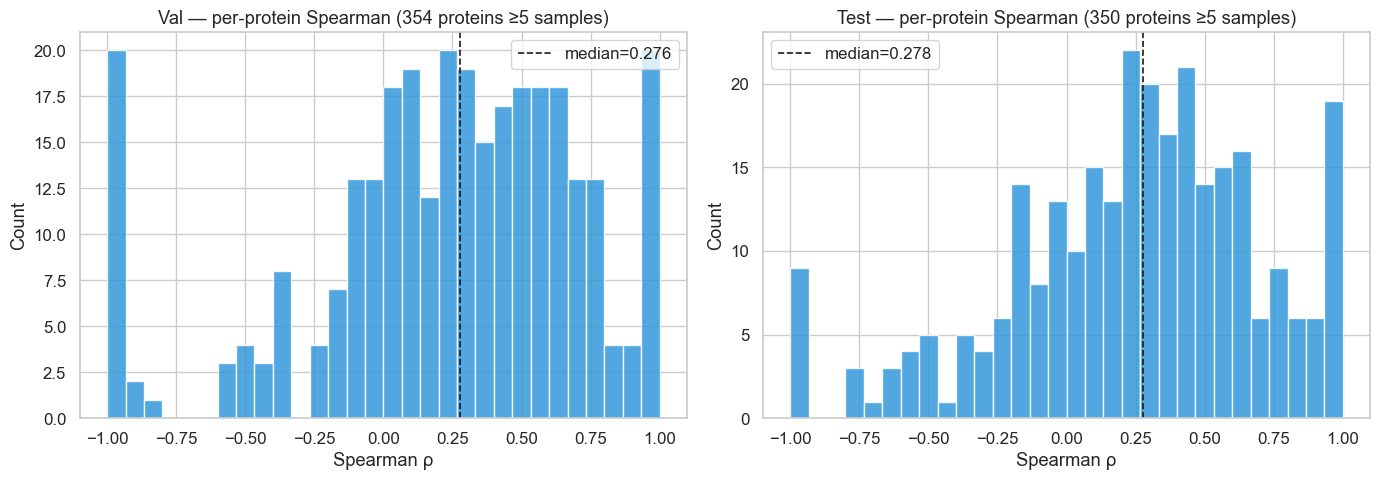

Val  — mean: 0.2276  median: 0.2757  <0: 78 proteins
Test — mean: 0.2436  median: 0.2783  <0: 76 proteins


In [11]:
def per_protein_spearman(df, pred_col='pred_pIC50', target_col='pIC50', min_samples=5):
    rows = []
    for protein, grp in df.groupby('protein'):
        if len(grp) < min_samples:
            continue
        sp = spearmanr(grp[target_col], grp[pred_col]).statistic
        rows.append({'protein': protein, 'spearman': sp,
                     'n': len(grp), 'family': grp['family'].iloc[0]})
    return pd.DataFrame(rows).sort_values('spearman', ascending=False)

val_pp  = per_protein_spearman(val_df)
test_pp = per_protein_spearman(test_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, pp) in zip(axes, [('Val', val_pp), ('Test', test_pp)]):
    ax.hist(pp['spearman'], bins=30, edgecolor='white', color='#3498db', alpha=0.85)
    ax.axvline(pp['spearman'].median(), color='k', linestyle='--', linewidth=1.2,
               label=f'median={pp["spearman"].median():.3f}')
    ax.set_title(f'{label} — per-protein Spearman ({len(pp):,} proteins ≥5 samples)')
    ax.set_xlabel('Spearman ρ')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig('../checkpoints/per_protein_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Val  — mean: {val_pp["spearman"].mean():.4f}  '
      f'median: {val_pp["spearman"].median():.4f}  '
      f'<0: {(val_pp["spearman"]<0).sum()} proteins')
print(f'Test — mean: {test_pp["spearman"].mean():.4f}  '
      f'median: {test_pp["spearman"].median():.4f}  '
      f'<0: {(test_pp["spearman"]<0).sum()} proteins')

## 7. Best and worst proteins (test set)

In [12]:
top10    = test_pp.head(10)[['protein', 'family', 'n', 'spearman']]
bottom10 = test_pp.tail(10)[['protein', 'family', 'n', 'spearman']]

print('── Top 10 proteins (test) ──')
print(top10.to_string(index=False))
print()
print('── Bottom 10 proteins (test) ──')
print(bottom10.to_string(index=False))

── Top 10 proteins (test) ──
protein      family  n  spearman
 P49290      enzyme 10       1.0
 Q8NEV4      kinase 25       1.0
 P23944       other 20       1.0
 P47745       other 20       1.0
 A3QR02 phosphatase 10       1.0
 P50482       other 10       1.0
 P50897 phosphatase 15       1.0
 P53985       other 25       1.0
 P97629      enzyme 20       1.0
 Q76LX8      enzyme 20       1.0

── Bottom 10 proteins (test) ──
protein family  n  spearman
 Q8WVB3 enzyme 10       NaN
 Q92995 enzyme 10       NaN
 Q9BDP5 enzyme  5       NaN
 Q9MYJ9  other  5       NaN
 Q9NR71 enzyme 20       NaN
 Q9NRC8 enzyme 10       NaN
 Q9NS75  other 10       NaN
 Q9NWT8  other 10       NaN
 Q9Y2H9 kinase 15       NaN
 Q9Y745  other  5       NaN


/var/folders/cq/_rhlqkqs7tqb1mb8ksc9mn6h0000gn/T/ipykernel_34405/80124987.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp  = spearmanr(grp['pIC50'], grp['pred_pIC50']).statistic


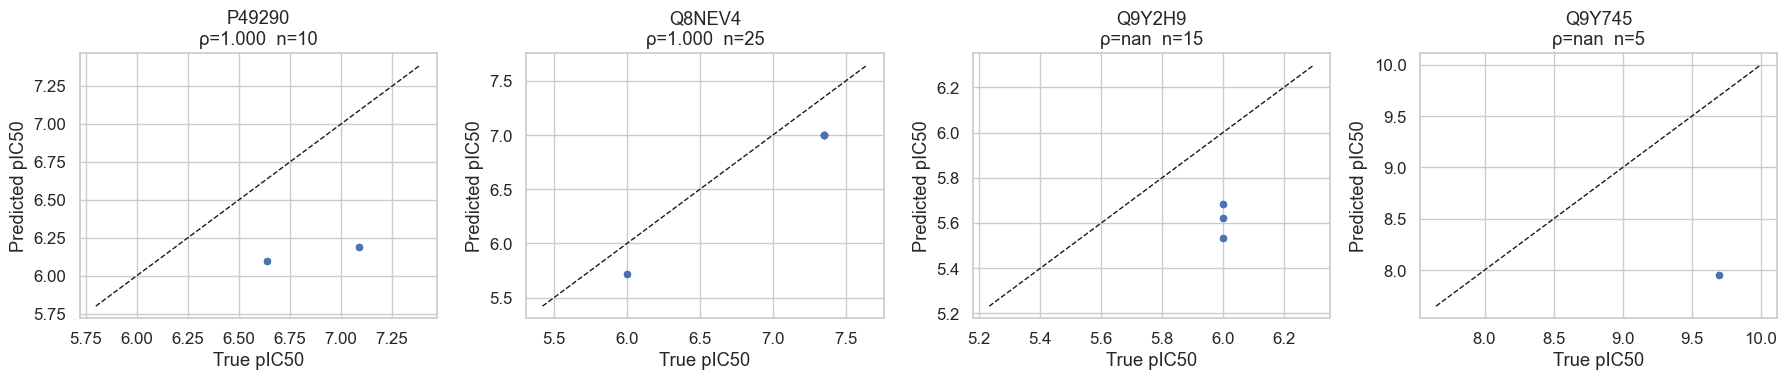

In [13]:
# Scatter for the 2 best and 2 worst proteins
proteins_to_plot = test_pp.head(2)['protein'].tolist() + test_pp.tail(2)['protein'].tolist()
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, prot in zip(axes, proteins_to_plot):
    grp = test_df[test_df['protein'] == prot]
    sp  = spearmanr(grp['pIC50'], grp['pred_pIC50']).statistic
    ax.scatter(grp['pIC50'], grp['pred_pIC50'], s=18, alpha=0.6)
    lo = min(grp['pIC50'].min(), grp['pred_pIC50'].min()) - 0.3
    hi = max(grp['pIC50'].max(), grp['pred_pIC50'].max()) + 0.3
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
    ax.set_title(f'{prot}\nρ={sp:.3f}  n={len(grp)}')
    ax.set_xlabel('True pIC50')
    ax.set_ylabel('Predicted pIC50')

plt.tight_layout()
plt.savefig('../checkpoints/best_worst_proteins.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Baseline comparison — oracle vs docking scores

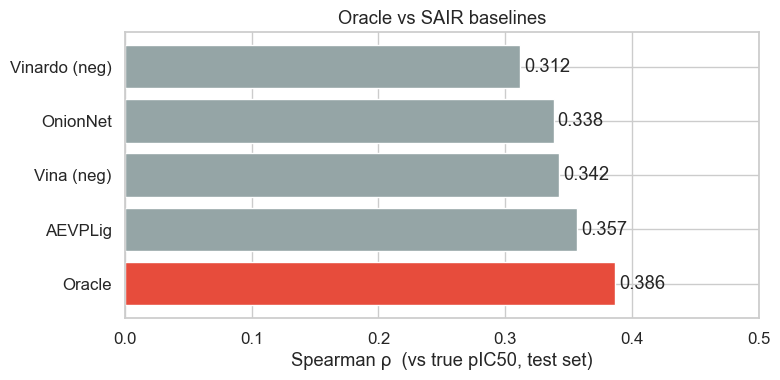

        model  spearman  pearson    mae   rmse
       Oracle    0.3864   0.3874 1.1300 1.4143
      AEVPLig    0.3565   0.3687 1.0917 1.3444
   Vina (neg)    0.3424   0.2361 2.9578 4.9296
     OnionNet    0.3381   0.3224 1.1576 1.4307
Vinardo (neg)    0.3118   0.2034 3.8144 6.6323


In [14]:
test_metrics = metrics_df[metrics_df['split'] == 'test'].drop(columns='split')
test_metrics = test_metrics.sort_values('spearman', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e74c3c' if m == 'Oracle' else '#95a5a6' for m in test_metrics['model']]
bars = ax.barh(test_metrics['model'], test_metrics['spearman'], color=colors, edgecolor='white')
ax.bar_label(bars, fmt='{:.3f}', padding=3)
ax.set_xlabel('Spearman ρ  (vs true pIC50, test set)')
ax.set_title('Oracle vs SAIR baselines')
ax.set_xlim(0, max(test_metrics['spearman'].max() + 0.1, 0.5))
plt.tight_layout()
plt.savefig('../checkpoints/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(test_metrics[['model','spearman','pearson','mae','rmse']].to_string(index=False, float_format='{:.4f}'.format))

## 9. Within-protein generalisation — test set

Three views using the test results already computed in sections 3 and 6:

1. **Calibration** — true vs predicted pIC50 distribution (is the model predicting the right range?)
2. **Per-family breakdown** — per-protein Spearman by protein family (where does the model work?)
3. **Quartile examples** — representative proteins at each Spearman quartile (what do good/median/bad fits look like?)

/var/folders/cq/_rhlqkqs7tqb1mb8ksc9mn6h0000gn/T/ipykernel_34405/557699071.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


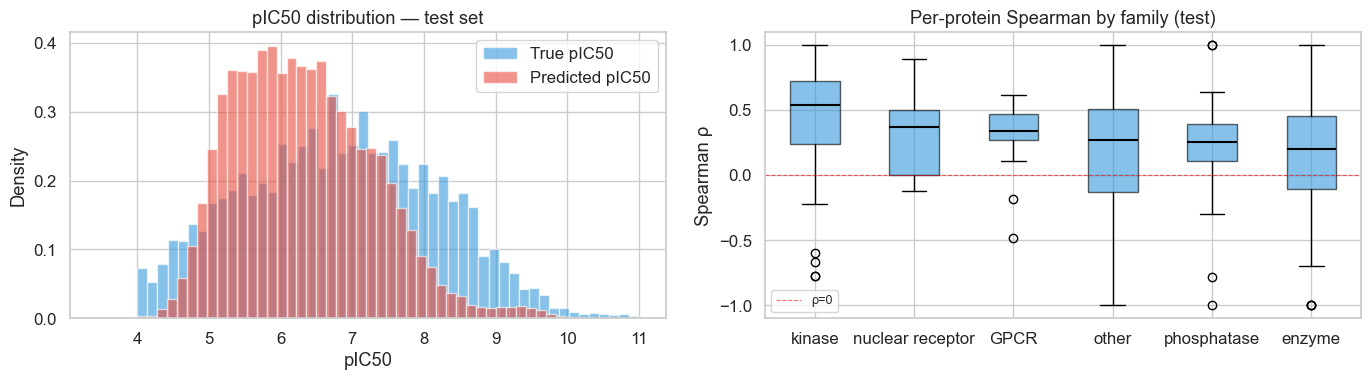

                    n  mean  median
family                             
kinase             62 0.423   0.540
nuclear receptor    9 0.313   0.371
GPCR               14 0.286   0.342
other              61 0.197   0.267
phosphatase        17 0.180   0.251
enzyme            122 0.175   0.199


In [21]:
# ── Part 1: calibration — true vs predicted pIC50 distribution ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(test_df['pIC50'],      bins=50, alpha=0.6, label='True pIC50',
        color='#3498db', edgecolor='white', density=True)
ax.hist(test_df['pred_pIC50'], bins=50, alpha=0.6, label='Predicted pIC50',
        color='#e74c3c', edgecolor='white', density=True)
ax.set_title('pIC50 distribution — test set')
ax.set_xlabel('pIC50')
ax.set_ylabel('Density')
ax.legend()

# ── Part 2: per-family per-protein Spearman ───────────────────────────────────
test_pp_clean = test_pp.dropna(subset=['spearman'])
family_order  = (test_pp_clean.groupby('family')['spearman']
                 .median().sort_values(ascending=False).index.tolist())

ax = axes[1]
ax.boxplot(
    [test_pp_clean[test_pp_clean['family'] == f]['spearman'].values for f in family_order],
    labels=family_order, patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6),
    medianprops=dict(color='black', linewidth=1.5),
)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='ρ=0')
ax.set_title('Per-protein Spearman by family (test)')
ax.set_ylabel('Spearman ρ')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../checkpoints/generalisation_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

family_summary = (test_pp_clean.groupby('family')['spearman']
                  .agg(n='count', mean='mean', median='median')
                  .sort_values('median', ascending=False))
print(family_summary.to_string(float_format='{:.3f}'.format))

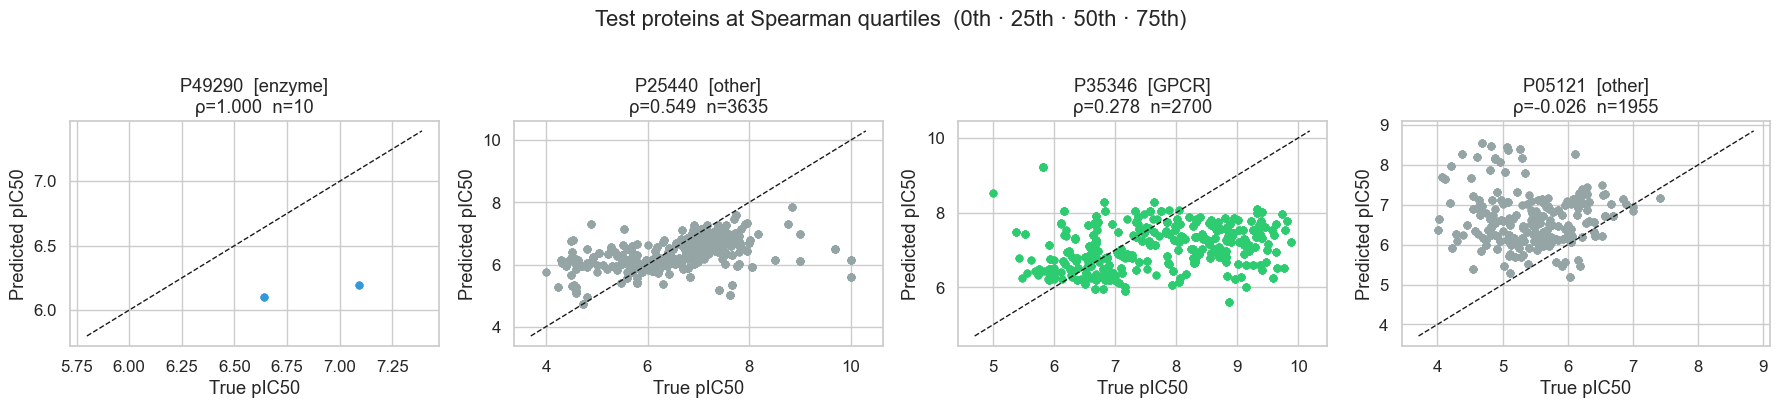

In [22]:
# ── Part 3: representative proteins at each Spearman quartile ─────────────────
# Shows what good / median / poor fits actually look like within a protein.
quartile_positions = [0.0, 0.25, 0.50, 0.75]
selected = [
    test_pp_clean.iloc[int(q * (len(test_pp_clean) - 1))]
    for q in quartile_positions
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, row in zip(axes, selected):
    prot = row['protein']
    grp  = test_df[test_df['protein'] == prot]
    color = FAMILY_COLORS.get(row['family'], '#95a5a6')
    ax.scatter(grp['pIC50'], grp['pred_pIC50'], s=22, alpha=0.65, c=color)
    lo = min(grp['pIC50'].min(), grp['pred_pIC50'].min()) - 0.3
    hi = max(grp['pIC50'].max(), grp['pred_pIC50'].max()) + 0.3
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
    ax.set_title(f'{prot}  [{row["family"]}]\nρ={row["spearman"]:.3f}  n={int(row["n"])}')
    ax.set_xlabel('True pIC50')
    ax.set_ylabel('Predicted pIC50')

plt.suptitle('Test proteins at Spearman quartiles  (0th · 25th · 50th · 75th)', y=1.02)
plt.tight_layout()
plt.savefig('../checkpoints/quartile_proteins.png', dpi=150, bbox_inches='tight')
plt.show()